# Inference

Load the trained model from `./saves/qc_params-new/` and run the full pipeline (diffusion sampling + post-optimization) on a handful of targets from `../bench_utils/targets_param.npy`.

For each target we plot the circuit returned by the diffusion model and the circuit after post-optimization, and report the process **infidelity**
$$1 - F_{\mathrm{pro}}(U_{\mathrm{target}}, U_{\mathrm{circ}}) = 1 - \frac{|\operatorname{Tr}(U_{\mathrm{target}}^{\dagger} U_{\mathrm{circ}})|^2}{d^2}$$
at each stage (smaller is better).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from qiskit.quantum_info import Operator

from genQC.imports import *
import genQC.util as util
from genQC.pipeline.diffusion_pipeline import DiffusionPipeline
from genQC.platform.simulation.qcircuit_sim import instruction_name_to_qiskit_gate
from genQC.platform.qcircuit_dataset_construction import decode_circuit
from genQC.inference.infer_compilation import generate_comp_tensors, convert_tensors_to_circuits

from fast_optim import optimize_qc_parameters_fast

In [2]:
device = util.infer_torch_device()
util.MemoryCleaner.purge_mem()
print("device:", device)

device: cpu


## Load the trained pipeline

In [3]:
model_path = "./saves/qc_params-new/"
pipeline = DiffusionPipeline.from_config_file(model_path, device)

pipeline.guidance_sample_mode = "rescaled"
pipeline.scheduler.set_timesteps(20)

gate_pool = [instruction_name_to_qiskit_gate(g) for g in pipeline.gate_pool]
print("gate pool:", pipeline.gate_pool)

[INFO]: `genQC.models.unet_qc.QC_Compilation_UNet` instantiated from given config on cpu.
[INFO]: `genQC.models.frozen_open_clip.CachedFrozenOpenCLIPEmbedder` instantiated from given config on cpu.
[INFO]: `genQC.models.frozen_open_clip.CachedFrozenOpenCLIPEmbedder`. No save_path` provided. No state dict loaded.
gate pool: ['rx', 'ry', 'rxx']


## Load target unitaries

`targets_param.npy` is a `(N, 8, 8)` array of 3-qubit unitaries.

In [4]:
targets = np.load("../bench_utils/targets_param.npy")
print("targets shape:", targets.shape)

# Quick unitarity check on the first one.
U0 = targets[0]
assert np.allclose(U0.conj().T @ U0, np.eye(U0.shape[0]), atol=1e-6)

targets shape: (10000, 8, 8)


## Helpers

- `process_infidelity` — $1 - |Tr(U^\dagger V)|^2/d^2$, phase-invariant.
- `compile_target` — runs the diffusion model and returns the best circuit (lowest infidelity to `U_target`) out of `samples` candidates.
- `run_example` — compiles a target, applies post-optimization, and plots the diffusion output alongside the post-optimized circuit.

In [5]:
NUM_QUBITS = 3
MAX_GATES  = 12
PROMPT     = "Compile using: ['rx', 'ry', 'rxx']"
G          = 7.5
SAMPLES    = 128


def process_infidelity(U_target: np.ndarray, qc) -> float:
    U_circ = Operator(qc).data
    d = U_target.shape[0]
    s = np.trace(U_target.conj().T @ U_circ)
    F = float(np.clip((np.abs(s) ** 2) / (d * d), 0.0, 1.0))
    return 1.0 - F


def compile_target(U_target: np.ndarray, samples: int = SAMPLES):
    """Run the diffusion model and return (best_qc, best_infidelity, all_qcs)."""
    U_r = torch.Tensor(np.real(U_target))
    U_i = torch.Tensor(np.imag(U_target))
    U_tensor = torch.stack([U_r, U_i], dim=0)

    out_tensor, params = generate_comp_tensors(
        pipeline, PROMPT, U_tensor,
        samples, NUM_QUBITS, NUM_QUBITS, MAX_GATES, G,
        unique=True,
    )

    qc_list, _ = convert_tensors_to_circuits(out_tensor, gate_pool, params_tensor=params)
    if not qc_list:
        raise RuntimeError("diffusion produced no decodable circuits")

    infids = [process_infidelity(U_target, qc) for qc in qc_list]
    best_idx = int(np.argmin(infids))
    return qc_list[best_idx], infids[best_idx], qc_list


def run_example(idx: int, samples: int = SAMPLES, opt_steps: int = 100, opt_lr: float = 0.1):
    U_target = targets[idx]
    print(f"=== target #{idx} ===")

    qc_diff, infid_diff, all_qcs = compile_target(U_target, samples=samples)
    print(f"sampled {len(all_qcs)} unique circuits   best infidelity (diffusion): {infid_diff:.6f}")

    U_t_torch = torch.tensor(U_target, dtype=torch.complex128)
    _, qc_opt, _ = optimize_qc_parameters_fast(
        qc_diff, U_t_torch, steps=opt_steps, lr=opt_lr, verbose=False,
    )
    infid_opt = process_infidelity(U_target, qc_opt)
    print(f"infidelity after post-optimization:           {infid_opt:.6f}")
    print(f"Δ infidelity:                                  {infid_opt - infid_diff:+.6f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    qc_diff.draw("mpl", plot_barriers=False, ax=axes[0])
    axes[0].set_title(f"target #{idx}  diffusion output\n 1 - F = {infid_diff:.4f}")
    qc_opt.draw("mpl", plot_barriers=False, ax=axes[1])
    axes[1].set_title(f"target #{idx}  after post-optimization\n 1 - F = {infid_opt:.4f}")
    plt.tight_layout()
    plt.show()

    return {
        "idx": idx,
        "qc_diff": qc_diff,
        "qc_opt": qc_opt,
        "infid_diff": infid_diff,
        "infid_opt": infid_opt,
    }

## Run on a few example targets

=== target #0 ===
sampled 128 unique circuits   best infidelity (diffusion): 0.380570
infidelity after post-optimization:           0.029929
Δ infidelity:                                  -0.350640


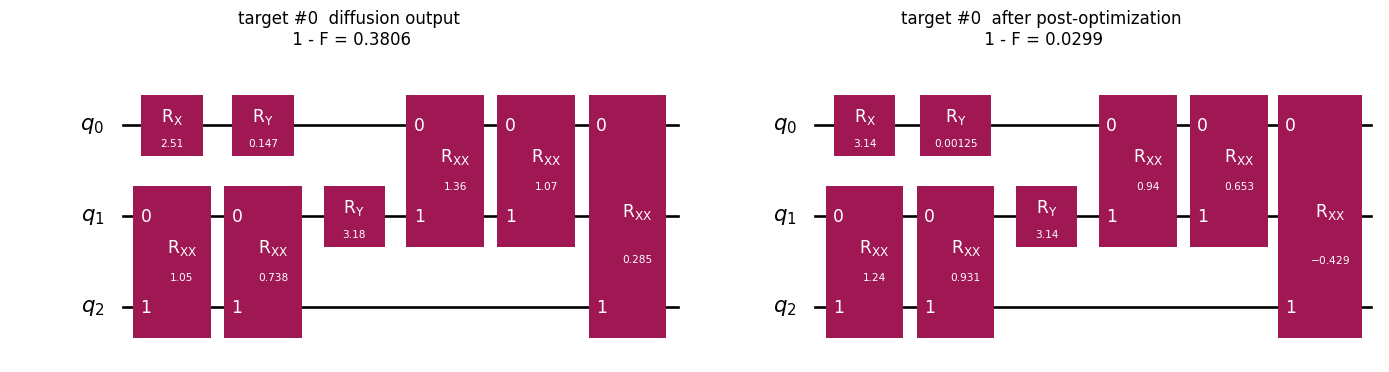

=== target #1 ===
sampled 128 unique circuits   best infidelity (diffusion): 0.690606
infidelity after post-optimization:           0.494938
Δ infidelity:                                  -0.195668


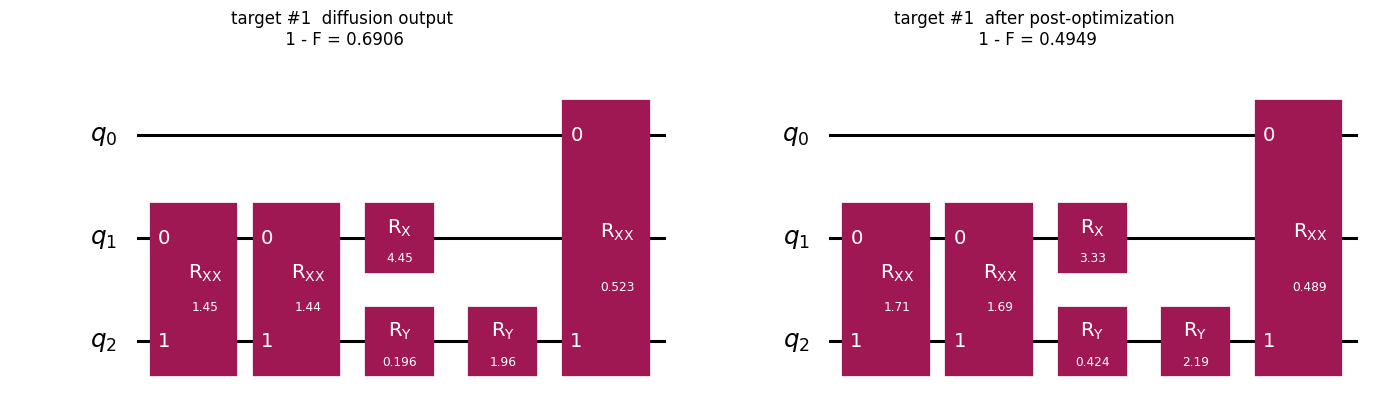

=== target #2 ===
sampled 128 unique circuits   best infidelity (diffusion): 0.743001
infidelity after post-optimization:           0.535462
Δ infidelity:                                  -0.207539


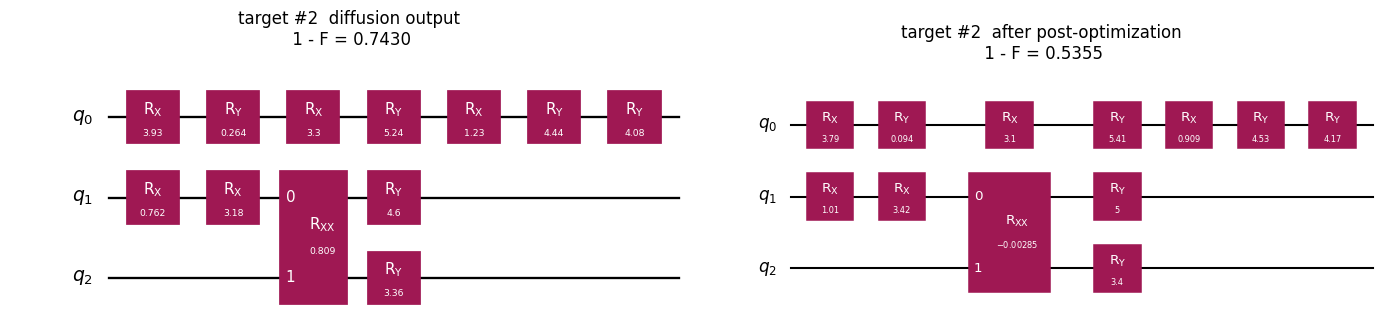

=== target #3 ===
sampled 128 unique circuits   best infidelity (diffusion): 0.587333
infidelity after post-optimization:           0.129789
Δ infidelity:                                  -0.457544


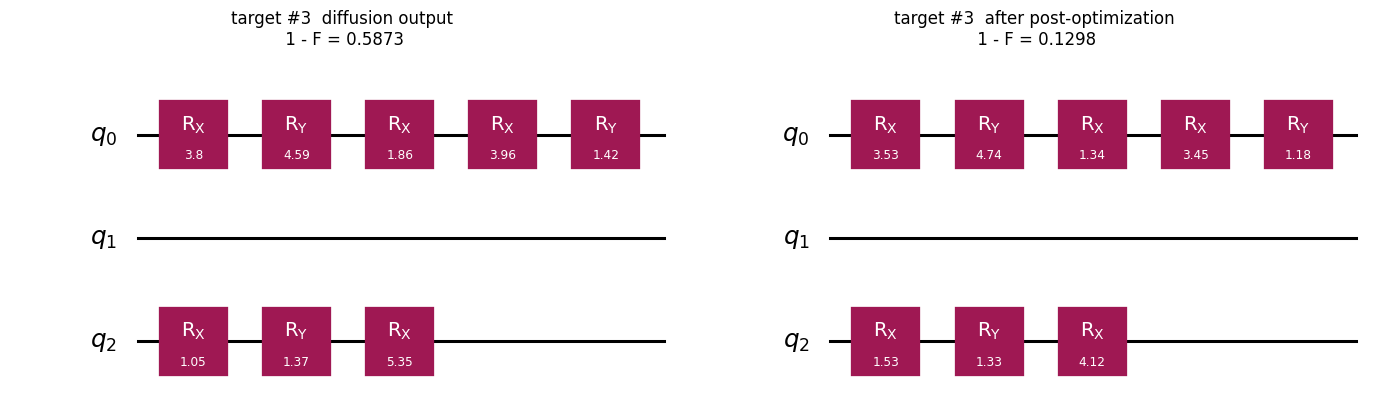

=== target #4 ===
sampled 125 unique circuits   best infidelity (diffusion): 0.651993
infidelity after post-optimization:           0.251723
Δ infidelity:                                  -0.400270


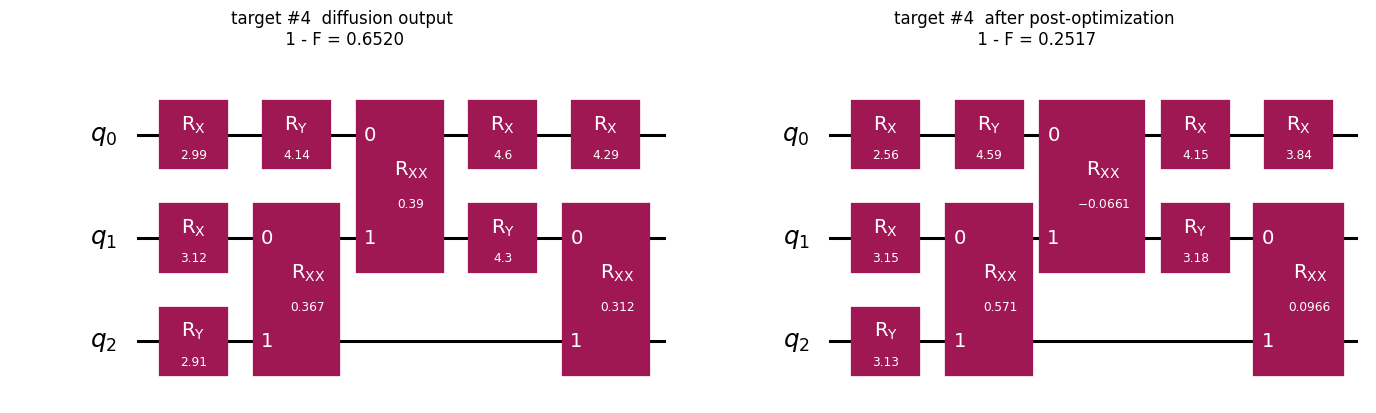

In [6]:
example_indices = [0, 1, 2, 3, 4]
results = [run_example(i) for i in example_indices]

## Summary table

In [7]:
print(f"{'idx':>4}  {'1-F diffusion':>14}  {'1-F optimized':>14}  {'Δ(1-F)':>10}")
print("-" * 52)
for r in results:
    print(f"{r['idx']:>4}  {r['infid_diff']:>14.6f}  {r['infid_opt']:>14.6f}  {r['infid_opt']-r['infid_diff']:>+10.6f}")

 idx   1-F diffusion   1-F optimized      Δ(1-F)
----------------------------------------------------
   0        0.380570        0.029929   -0.350640
   1        0.690606        0.494938   -0.195668
   2        0.743001        0.535462   -0.207539
   3        0.587333        0.129789   -0.457544
   4        0.651993        0.251723   -0.400270
